# RQ4 — Does the proficiency of the code in a PR affect the review effort it receives?

Companion to `rq3_task_type_proficiency.ipynb`. Same three groups, same per-PR
proficiency measures; the outcome here is the human review effort each PR attracted.

**Independent variables** (both already in the per-group CSVs)

| Variable | Meaning |
|---|---|
| `cefr_mean` | ordinal CEFR mean over the PR's constructs, A1=1 … C2=6 — the measure used for RQ2's repository-paired Wilcoxon |
| `c1c2` | number of proficient (C1 + C2) constructs the PR introduces |

Both are standardised, so every coefficient is the effect of a **one standard deviation
increase**. `c1c2` is log(1+x) transformed first: it is extremely right-skewed (median 1,
maximum 1,015).

**Dependent variables** — all restricted to *human* activity, because bots write 41% of
the reviews and 70% of the comments on agent PRs.

| Variable | Meaning |
|---|---|
| `rounds` | human review submissions (`n_reviews_human`) |
| `comments` | review and conversation comments written by humans other than the PR author |
| `changes` | whether any human reviewer requested changes |

**Models.** PR size is the confound: bigger PRs attract both more comments and, simply by
holding more code, more proficient constructs. Every estimate below therefore comes from a
regression that controls for added lines, deleted lines, changed files and task type, with
standard errors clustered by repository. Counts use negative binomial regression;
the yes/no outcome uses logistic regression.

In [1]:
import os
import warnings
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP
from patsy import dmatrices, dmatrix

warnings.simplefilter('ignore')

# Locate the package root (the folder holding data/ and README.md) by walking up from
# the working directory, so this notebook runs from its own folder or from the root.
ROOT = os.getcwd()
while not (os.path.isdir(os.path.join(ROOT, 'data'))
           and os.path.exists(os.path.join(ROOT, 'README.md'))):
    _parent = os.path.dirname(ROOT)
    if _parent == ROOT:
        raise RuntimeError('could not locate the package root from ' + os.getcwd())
    ROOT = _parent

DATA = os.path.join(ROOT, 'data')                # shared per-PR tables
RQ_DIR = os.path.join(ROOT, 'rq4')              # this notebook's own folder
FIG_DIR = os.path.join(RQ_DIR, 'figures')
TAB_DIR = os.path.join(RQ_DIR, 'tables')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

LEVELS = ['A1', 'A2', 'B1', 'B2', 'C1', 'C2']
GROUPS = ['AI agents', 'Human', 'Human (pre-ChatGPT)']
SHORT = {'AI agents': 'agents', 'Human': 'human', 'Human (pre-ChatGPT)': 'pre_chatgpt'}
FILES = {
    'AI agents':           'rq3_agent_prs_with_task_type.csv',
    'Human':               'rq3_human_prs_with_task_type.csv',
    'Human (pre-ChatGPT)': 'rq3_pre_chatgpt_prs_with_task_type.csv',
}
COMMENT_AUTHORS = 'rq4_pr_comment_authors.csv'   # human/bot split, from rq4_fetch_comment_authors.py

# Task types with few PRs are pooled into "other" so the dummies stay estimable.
KEEP_TASKS = ['feat', 'fix', 'refactor', 'test', 'docs']
TASK_ORDER = ['feat', 'fix', 'refactor', 'test', 'docs', 'other']

IVS = {'c1c2_z': 'C1+C2 constructs'}
OUTCOMES = {'rounds': 'Review rounds', 'comments': 'Review comments',
            'changes': 'Changes requested'}

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
print('package root:', os.path.basename(ROOT))

package root: agent-cefr-journal-study


## 1. Load, check, and derive the model variables

The three per-group CSVs already carry the CEFR counts, the proficiency measures, the PR
size controls and the review metrics. `status` records whether the PR could still be read
from GitHub; 15 PRs were deleted upstream and are dropped here.

In [2]:
frames = []
for g, f in FILES.items():
    d = pd.read_csv(os.path.join(DATA, f), dtype={'pr_id': str})
    assert (d['group'] == g).all(), f'{f}: unexpected group label'
    frames.append(d)
raw = pd.concat(frames, ignore_index=True)

print('PRs before the status filter:', len(raw))
print(raw.groupby('group')['status'].value_counts().rename('n').to_frame().T)

df = raw[raw['status'] == 'ok'].copy()
df['group'] = pd.Categorical(df['group'], categories=GROUPS, ordered=True)

# Same consistency checks as the RQ3 notebook: the shipped columns must match the counts.
assert df['pr_id'].is_unique
assert (df[LEVELS].sum(axis=1) == df['total']).all()
assert ((df['C1'] + df['C2']) == df['c1c2']).all()
ordinal = (df[LEVELS] * np.arange(1, 7)).sum(axis=1) / df['total']
assert np.allclose(ordinal, df['cefr_mean'], atol=1e-3)
print('\nPRs after the status filter:', len(df))

PRs before the status filter: 1483
group  AI agents     Human     Human (pre-ChatGPT)
status        ok 404    ok 404                  ok
n            479   2   524  13                 465

PRs after the status filter: 1468


### Human-only comment counts

`n_review_comments` and `n_issue_comments` are GitHub's own counters and **include bot
comments**. `rq4_fetch_comment_authors.py` re-fetches each PR's comments and splits them
by author, which is what the human-only outcome needs. If that file is absent the notebook
falls back to the raw counters and flags it, so every result stays reproducible either way.

In [3]:
ca_path = os.path.join(DATA, COMMENT_AUTHORS)
HUMAN_COMMENTS = os.path.exists(ca_path)

if HUMAN_COMMENTS:
    ca = pd.read_csv(ca_path, dtype={'pr_id': str})
    cols = ['pr_id', 'n_review_comments_human', 'n_issue_comments_human',
            'n_review_comments_bot', 'n_issue_comments_bot',
            'n_review_comments_author', 'n_issue_comments_author', 'comment_status']
    df = df.merge(ca[cols], on='pr_id', how='left')
    miss = int(df['n_review_comments_human'].isna().sum())
    print(f'comment author split merged; {len(df) - miss}/{len(df)} PRs matched')
    for c in cols[1:-1]:
        df[c] = df[c].fillna(0).astype(int)

    # Reconcile against the counters stored by the first fetch.
    for kind in ['review', 'issue']:
        tot = df[f'n_{kind}_comments_human'] + df[f'n_{kind}_comments_bot']
        agree = (tot == df[f'n_{kind}_comments'].fillna(0)).mean()
        print(f'  {kind:6s} comments reconcile with the stored counter for {agree*100:.1f}% of PRs')

    df['comments_human'] = df['n_review_comments_human'] + df['n_issue_comments_human']
    df['comments_bot'] = df['n_review_comments_bot'] + df['n_issue_comments_bot']
    df['comments_author'] = df['n_review_comments_author'] + df['n_issue_comments_author']
    # The PR author's own replies are not reviewer effort, and leaving them in would bias
    # the between-group comparison: on agent PRs the author is a bot and is already
    # excluded by the bot filter, while on human PRs the author writes a large share of
    # the human comments.
    df['comments'] = df['comments_human'] - df['comments_author']
else:
    print('!! rq4_pr_comment_authors.csv not found -- falling back to GitHub\'s raw counters,')
    print('   which include bot comments. Run rq4_fetch_comment_authors.py for the human-only split.')
    df['comments'] = (df['n_review_comments'].fillna(0) + df['n_issue_comments'].fillna(0))
    df['comments_human'] = df['comments']
    df['comments_bot'] = np.nan
    df['comments_author'] = np.nan

df['comments'] = df['comments'].astype(int)
df['rounds'] = df['n_reviews_human'].fillna(0).astype(int)
df['changes'] = df['any_changes_requested'].fillna(0).astype(int)
print('\nHUMAN_COMMENTS =', HUMAN_COMMENTS)

comment author split merged; 1468/1468 PRs matched
  review comments reconcile with the stored counter for 100.0% of PRs
  issue  comments reconcile with the stored counter for 100.0% of PRs

HUMAN_COMMENTS = True


In [4]:
# --- predictors ---------------------------------------------------------------
df['task'] = np.where(df['type'].isin(KEEP_TASKS), df['type'], 'other')
df['task'] = pd.Categorical(df['task'], categories=TASK_ORDER)   # feat is the reference

for col, src in [('log_add', 'additions'), ('log_del', 'deletions'),
                 ('log_files', 'changed_files')]:
    df[col] = np.log1p(df[src].astype(float))

df['log_c1c2'] = np.log1p(df['c1c2'].astype(float))


def z(s):
    return (s - s.mean()) / s.std(ddof=0)


# Standardised on the pooled sample so the three groups share one scale.
df['cefr_z'] = z(df['cefr_mean'])
df['c1c2_z'] = z(df['log_c1c2'])
df['c1c2pct_z'] = z(df['c1c2_pct'].fillna(0))

SD = {'cefr_mean': df['cefr_mean'].std(ddof=0), 'log_c1c2': df['log_c1c2'].std(ddof=0)}
print('1 SD of the ordinal CEFR mean  =', round(SD['cefr_mean'], 4))
print('1 SD of log(1 + C1+C2)         =', round(SD['log_c1c2'], 4),
      f'(a factor of {np.exp(SD["log_c1c2"]):.2f} in 1 + C1+C2)')
print('\ntask types after pooling:')
print(pd.crosstab(df['task'], df['group']))

1 SD of the ordinal CEFR mean  = 0.5889
1 SD of log(1 + C1+C2)         = 1.1444 (a factor of 3.14 in 1 + C1+C2)

task types after pooling:
group     AI agents  Human  Human (pre-ChatGPT)
task                                           
feat            230    249                  120
fix             162    173                  167
refactor         35     36                   36
test             21     17                   35
docs             15     14                   16
other            16     35                   91


## 2. How much review effort is there to explain?

The RQ4 proposal asks for this check before any modelling: if almost every PR received no
human review at all, RQ4 would have to be reported descriptively rather than fitted.

In [5]:
def desc(d):
    r, c = d['rounds'], d['comments']
    out = {
        'PRs': len(d), 'repositories': d['repo'].nunique(),
        'rounds: zero %': 100 * (r == 0).mean(), 'rounds: median': r.median(),
        'rounds: mean': r.mean(), 'rounds: max': r.max(),
        'comments: zero %': 100 * (c == 0).mean(), 'comments: median': c.median(),
        'comments: mean': c.mean(), 'comments: max': c.max(),
        'changes requested %': 100 * d['changes'].mean(),
        'reviews by bots %': 100 * d['n_reviews_bot'].fillna(0).sum()
                             / max(1, d['n_reviews_total'].fillna(0).sum()),
    }
    if HUMAN_COMMENTS:
        allc = d['comments_human'].sum() + d['comments_bot'].sum()
        out['comments by bots %'] = 100 * d['comments_bot'].sum() / max(1, allc)
        out['human comments by the PR author %'] = (100 * d['comments_author'].sum()
                                                    / max(1, d['comments_human'].sum()))
    return pd.Series(out)


descriptives = pd.DataFrame({g: desc(d) for g, d in df.groupby('group', observed=True)})
print(descriptives.to_string())

                                   AI agents   Human  Human (pre-ChatGPT)
PRs                                  479.000 524.000              465.000
repositories                         128.000 133.000               49.000
rounds: zero %                        32.150  29.771               37.204
rounds: median                         1.000   1.000                1.000
rounds: mean                           2.259   2.260                1.815
rounds: max                           32.000  50.000               33.000
comments: zero %                      40.501  52.290               56.774
comments: median                       1.000   0.000                0.000
comments: mean                         3.296   1.775                1.699
comments: max                         50.000  35.000               31.000
changes requested %                   10.438   4.962                4.731
reviews by bots %                     41.671  18.062                4.091
comments by bots %                    

In [6]:
# Dispersion: for a Poisson process the variance would equal the mean. It does not.
disp = pd.DataFrame({
    g: {f'{o} var/mean': d[o].var() / max(1e-9, d[o].mean()) for o in ['rounds', 'comments']}
    for g, d in df.groupby('group', observed=True)})
print(disp.to_string())
print('\nA ratio far above 1 is overdispersion, which is why the counts are modelled')
print('with a negative binomial rather than a Poisson regression.')

                   AI agents  Human  Human (pre-ChatGPT)
rounds var/mean        6.083  7.975                5.567
comments var/mean     13.539  7.573                7.045

A ratio far above 1 is overdispersion, which is why the counts are modelled
with a negative binomial rather than a Poisson regression.


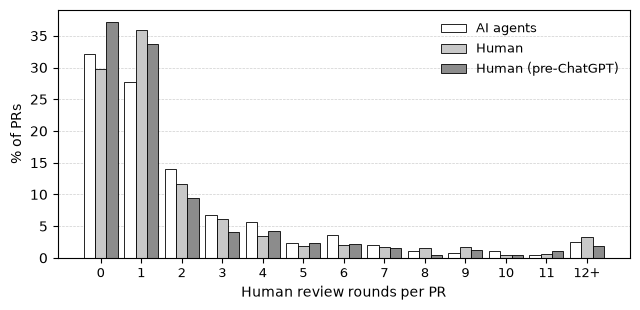

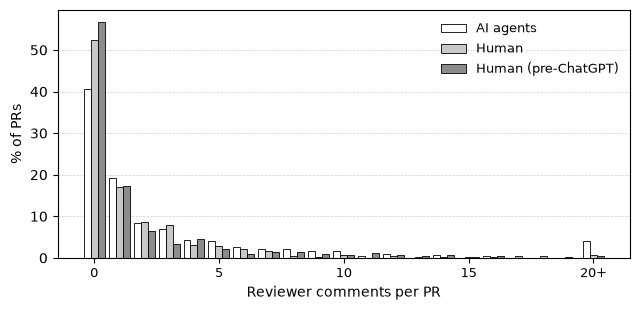

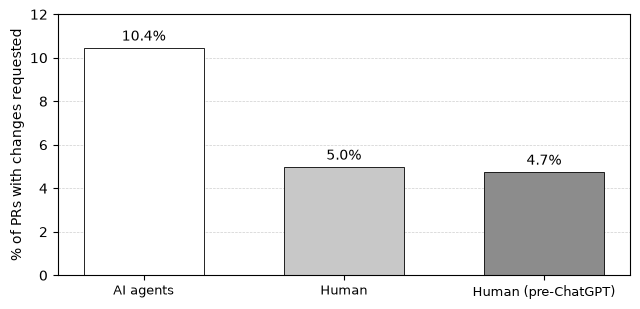

In [7]:
# Figures: the distribution of review effort per group, one file per measure.
FACE = ['#ffffff', '#c8c8c8', '#8c8c8c']
FIGSIZE = (6.5, 3.2)


def save_fig(fig, name):
    fig.tight_layout()
    for ext in ('pdf', 'png'):
        fig.savefig(os.path.join(FIG_DIR, f'{name}.{ext}'),
                    bbox_inches='tight', dpi=200 if ext == 'png' else None)
    plt.show()


# The two counts, as grouped histograms; the long tail is folded into the last bar.
for col, label, cap, step, name in [
        ('rounds', 'Human review rounds per PR', 12, 1, 'rq4_dist_rounds'),
        ('comments', 'Reviewer comments per PR', 20, 5, 'rq4_dist_comments')]:
    fig, ax = plt.subplots(figsize=FIGSIZE)
    bins = np.arange(0, cap + 2) - 0.5
    for i, g in enumerate(GROUPS):
        v = df.loc[df.group == g, col].clip(upper=cap)
        h, _ = np.histogram(v, bins=bins)
        ax.bar(np.arange(0, cap + 1) + (i - 1) * 0.28, 100 * h / h.sum(), width=0.28,
               facecolor=FACE[i], edgecolor='black', linewidth=0.6, label=g)
    ticks = list(range(0, cap + 1, step))
    ax.set_xticks(ticks)
    ax.set_xticklabels([f'{t}+' if t == cap else str(t) for t in ticks], fontsize=9)
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('% of PRs', fontsize=10)
    ax.grid(True, axis='y', ls='--', lw=0.5, alpha=0.6)
    ax.set_axisbelow(True)
    ax.legend(fontsize=9, frameon=False)
    save_fig(fig, name)

# The binary outcome, as one bar per group.
fig, ax = plt.subplots(figsize=FIGSIZE)
vals = [100 * df.loc[df.group == g, 'changes'].mean() for g in GROUPS]
bars = ax.bar(range(3), vals, width=0.6, edgecolor='black', linewidth=0.6)
for b, f, v in zip(bars, FACE, vals):
    b.set_facecolor(f)
    ax.text(b.get_x() + b.get_width() / 2, v + 0.2, f'{v:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_ylim(0, max(vals) * 1.15)                      # headroom so the top label is not clipped
ax.set_xticks(range(3))
ax.set_xticklabels(GROUPS, fontsize=9)
ax.set_ylabel('% of PRs with changes requested', fontsize=10)
ax.grid(True, axis='y', ls='--', lw=0.5, alpha=0.6)
ax.set_axisbelow(True)
save_fig(fig, 'rq4_dist_changes')

## 3. Raw association, before controlling for size

Reported only to make the confound visible: PR size drives both proficiency and review
effort, so these raw correlations are not the answer to RQ4.

In [8]:
def holm(pvals):
    p = np.asarray(pvals, dtype=float)
    order = np.argsort(p)
    adj = np.empty_like(p)
    running = 0.0
    for rank, idx in enumerate(order):
        running = max(running, (len(p) - rank) * p[idx])
        adj[idx] = min(running, 1.0)
    return adj


rows = []
for g, d in df.groupby('group', observed=True):
    for xn, x in [('c1c2', d['c1c2']), ('additions', d['additions'])]:
        for yn in ['rounds', 'comments']:
            r, p = stats.spearmanr(x, d[yn])
            rows.append(dict(group=g, predictor=xn, outcome=yn, rho=r, p=p))
spear = pd.DataFrame(rows)
spear['p_holm'] = holm(spear['p'])
print(spear.pivot_table(index=['group', 'predictor'], columns='outcome',
                        values=['rho', 'p_holm']).to_string())

                                p_holm             rho       
outcome                       comments rounds comments rounds
group               predictor                                
AI agents           additions    0.093  0.093    0.107 -0.107
                    c1c2         0.048  0.882    0.121 -0.035
Human               additions    0.000  0.005    0.254  0.151
                    c1c2         0.000  0.015    0.188  0.134
Human (pre-ChatGPT) additions    0.014  0.907    0.144  0.005
                    c1c2         0.001  0.487    0.180  0.065


## 4. The models

One model per (group, outcome, proficiency measure). Counts use a negative binomial
regression, the yes/no outcome a logistic regression; both control for
`log(1+additions)`, `log(1+deletions)`, `log(1+changed files)` and task type, with
standard errors clustered by repository.

Coefficients are exponentiated: an **incidence rate ratio** for the counts (the
multiplicative change in the expected number of reviews or comments per 1 SD of
proficiency) and an **odds ratio** for changes requested. A value of 1 means proficiency
makes no difference.

In [9]:
CONTROLS = 'log_add + log_del + log_files + C(task)'


def fit_one(d, outcome, iv, kind, controls=CONTROLS):
    """One clustered model. Returns (result, formula) or (None, formula) if it fails."""
    formula = f'{outcome} ~ {iv} + {controls}'
    groups = d['repo'].astype('category').cat.codes.values
    kw = dict(cov_type='cluster', cov_kwds={'groups': groups}, maxiter=1000, disp=0)
    try:
        if kind == 'nb':
            res = smf.negativebinomial(formula, d).fit(**kw)
        else:
            # Newton can stall on the sparse changes-requested outcome; BFGS reaches the
            # same optimum and reports convergence honestly.
            res = smf.logit(formula, d).fit(method='bfgs', **kw)
        return res, formula
    except Exception as e:                                    # noqa: BLE001
        print(f'  FAILED {formula} on {len(d)} rows: {type(e).__name__}: {e}')
        return None, formula


def effect(res, iv):
    """Exponentiated coefficient of `iv` with its 95% CI and p-value."""
    lo, hi = res.conf_int().loc[iv]
    return dict(est=np.exp(res.params[iv]), lo=np.exp(lo), hi=np.exp(hi),
                p=res.pvalues[iv],
                converged=bool(res.mle_retvals.get('converged', True)))


def stars(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''

In [10]:
records, fits = [], {}
for g, d in df.groupby('group', observed=True):
    for outcome in OUTCOMES:
        kind = 'logit' if outcome == 'changes' else 'nb'
        for iv in IVS:
            res, _ = fit_one(d, outcome, iv, kind)
            if res is None:
                continue
            fits[(g, outcome, iv)] = res
            rec = dict(group=g, outcome=outcome, iv=iv, kind=kind,
                       n=int(res.nobs), repos=d['repo'].nunique(),
                       events=int(d['changes'].sum()) if outcome == 'changes' else np.nan,
                       alpha=float(res.params.get('alpha', np.nan)),
                       pseudo_r2=float(getattr(res, 'prsquared', np.nan)))
            rec.update(effect(res, iv))
            records.append(rec)

models = pd.DataFrame(records)
# Holm across the three proficiency tests within each group, one per outcome.
models['p_holm'] = np.concatenate([holm(s['p'].values)
                                   for _, s in models.groupby('group', sort=False)])
assert models['converged'].all(), models.loc[~models['converged']]
print(models[['group', 'outcome', 'iv', 'n', 'repos', 'est', 'lo', 'hi', 'p', 'p_holm',
              'alpha', 'pseudo_r2']].to_string(index=False))

              group  outcome     iv   n  repos   est    lo    hi     p  p_holm  alpha  pseudo_r2
          AI agents   rounds c1c2_z 479    128 1.115 0.948 1.311 0.190   0.258  1.265      0.017
          AI agents comments c1c2_z 479    128 1.161 0.958 1.407 0.129   0.258  2.300      0.023
          AI agents  changes c1c2_z 479    128 1.349 0.963 1.890 0.082   0.245    NaN      0.037
              Human   rounds c1c2_z 524    133 1.259 1.053 1.505 0.011   0.034  1.138      0.043
              Human comments c1c2_z 524    133 1.130 0.929 1.375 0.222   0.443  2.057      0.049
              Human  changes c1c2_z 524    133 1.247 0.695 2.240 0.459   0.459    NaN      0.114
Human (pre-ChatGPT)   rounds c1c2_z 465     49 1.257 1.035 1.528 0.021   0.053  1.327      0.022
Human (pre-ChatGPT) comments c1c2_z 465     49 1.243 0.983 1.572 0.069   0.069  2.917      0.025
Human (pre-ChatGPT)  changes c1c2_z 465     49 1.901 1.118 3.233 0.018   0.053    NaN      0.055


In [11]:
# The model table as it appears in the paper.
def cell(r):
    """Estimate, 95% CI and significance stars. Uses the Holm-adjusted p where one exists."""
    p = r['p_holm'] if 'p_holm' in r.index and pd.notna(r['p_holm']) else r['p']
    return f'{r.est:.2f} [{r.lo:.2f}, {r.hi:.2f}]{stars(p)}'


tab = models.copy()
tab['cellv'] = tab.apply(cell, axis=1)
main_tab = (tab.pivot_table(index=['group', 'iv'], columns='outcome', values='cellv',
                            aggfunc='first')
               .reindex(columns=list(OUTCOMES)))
main_tab.columns = [OUTCOMES[c] for c in main_tab.columns]
main_tab.index = pd.MultiIndex.from_tuples(
    [(g, IVS[i]) for g, i in main_tab.index], names=['Group', 'Proficiency measure'])
n_by_group = models.groupby('group', observed=True)[['n', 'repos']].first()
print(main_tab.to_string())
print('\nPRs and repositories per group:')
print(n_by_group.to_string())
print('\nIRR for the two count outcomes, OR for changes requested.')
print('Stars are Holm-adjusted within group: * p<0.05, ** p<0.01, *** p<0.001.')

                                              Review rounds    Review comments  Changes requested
Group               Proficiency measure                                                          
AI agents           C1+C2 constructs      1.11 [0.95, 1.31]  1.16 [0.96, 1.41]  1.35 [0.96, 1.89]
Human               C1+C2 constructs     1.26 [1.05, 1.51]*  1.13 [0.93, 1.38]  1.25 [0.69, 2.24]
Human (pre-ChatGPT) C1+C2 constructs      1.26 [1.03, 1.53]  1.24 [0.98, 1.57]  1.90 [1.12, 3.23]

PRs and repositories per group:
                       n  repos
group                          
AI agents            479    128
Human                524    133
Human (pre-ChatGPT)  465     49

IRR for the two count outcomes, OR for changes requested.
Stars are Holm-adjusted within group: * p<0.05, ** p<0.01, *** p<0.001.


## 5. Does proficiency buy the same scrutiny for agents as for humans?

The per-group models say whether proficiency predicts review effort *within* a group. To
compare the slopes *between* groups the model has to be fitted once on all PRs with a
proficiency-by-group interaction. The interaction term is the answer to the question the
methodology poses: does the same increase in proficiency attract more scrutiny when a
human wrote the code than when an agent did? AI agents are the reference group, so each
interaction is that group's slope relative to the agents'.

In [12]:
pooled_rows, pooled_fits = [], {}
gcodes = df['repo'].astype('category').cat.codes.values
df['grp'] = pd.Categorical(df['group'].astype(str), categories=GROUPS)

for outcome in OUTCOMES:
    kind = 'logit' if outcome == 'changes' else 'nb'
    for iv in IVS:
        formula = f'{outcome} ~ {iv}*C(grp) + {CONTROLS}'
        kw = dict(cov_type='cluster', cov_kwds={'groups': gcodes}, maxiter=1000, disp=0)
        res = (smf.negativebinomial(formula, df).fit(**kw) if kind == 'nb'
               else smf.logit(formula, df).fit(method='bfgs', **kw))
        pooled_fits[(outcome, iv)] = res
        for term, label in [(iv, 'AI agents (reference slope)'),
                            (f'{iv}:C(grp)[T.Human]', 'Human vs. agents'),
                            (f'{iv}:C(grp)[T.Human (pre-ChatGPT)]', 'Human (pre-ChatGPT) vs. agents')]:
            e = effect(res, term)
            pooled_rows.append(dict(outcome=outcome, iv=iv, term=label, **e))

pooled = pd.DataFrame(pooled_rows)
# The hypotheses of interest are the between-group slope differences, so the Holm family is
# the two interaction terms within an outcome (one per between-group comparison).
# The reference slope is not a between-group test and simply restates the per-group model.
pooled['p_holm'] = np.nan
mask = pooled['term'] != 'AI agents (reference slope)'
pooled.loc[mask, 'p_holm'] = np.concatenate(
    [holm(s['p'].values) for _, s in pooled[mask].groupby('outcome', sort=False)])
assert pooled['converged'].all()
print(pooled[['outcome', 'iv', 'term', 'est', 'lo', 'hi', 'p', 'p_holm']].to_string(index=False))

 outcome     iv                           term   est    lo    hi     p  p_holm
  rounds c1c2_z    AI agents (reference slope) 1.051 0.903 1.223 0.520     NaN
  rounds c1c2_z               Human vs. agents 1.243 0.997 1.549 0.053   0.106
  rounds c1c2_z Human (pre-ChatGPT) vs. agents 1.158 0.930 1.443 0.190   0.190
comments c1c2_z    AI agents (reference slope) 1.116 0.931 1.338 0.235     NaN
comments c1c2_z               Human vs. agents 1.060 0.824 1.364 0.650   1.000
comments c1c2_z Human (pre-ChatGPT) vs. agents 1.047 0.805 1.362 0.731   1.000
 changes c1c2_z    AI agents (reference slope) 1.235 0.892 1.709 0.204     NaN
 changes c1c2_z               Human vs. agents 1.411 0.836 2.382 0.197   0.395
 changes c1c2_z Human (pre-ChatGPT) vs. agents 1.262 0.824 1.934 0.285   0.395


In [13]:
pooled['cellv'] = pooled.apply(cell, axis=1)
pool_tab = (pooled.pivot_table(index=['iv', 'term'], columns='outcome', values='cellv',
                               aggfunc='first')
                  .reindex(columns=list(OUTCOMES)))
pool_tab.columns = [OUTCOMES[c] for c in pool_tab.columns]
pool_tab.index = pd.MultiIndex.from_tuples([(IVS[i], t) for i, t in pool_tab.index],
                                           names=['Proficiency measure', 'Term'])
print(pool_tab.to_string())
print(f'\nn = {len(df)} PRs across {df.repo.nunique()} repositories.')
print('An interaction above 1 means proficiency buys more scrutiny in that group than for agents.')

                                                        Review rounds    Review comments  Changes requested
Proficiency measure Term                                                                                   
C1+C2 constructs    AI agents (reference slope)     1.05 [0.90, 1.22]  1.12 [0.93, 1.34]  1.23 [0.89, 1.71]
                    Human (pre-ChatGPT) vs. agents  1.16 [0.93, 1.44]  1.05 [0.81, 1.36]  1.26 [0.82, 1.93]
                    Human vs. agents                1.24 [1.00, 1.55]  1.06 [0.82, 1.36]  1.41 [0.84, 2.38]

n = 1468 PRs across 234 repositories.
An interaction above 1 means proficiency buys more scrutiny in that group than for agents.


## 6. Robustness

Five ways the main models could be wrong, each re-fitted with the C1+C2 measure, which is
the one that carries the signal.

In [14]:
rob_rows = []


def rob(label, d, outcome, iv, kind, controls=CONTROLS, note=''):
    res, _ = fit_one(d, outcome, iv, kind, controls)
    if res is None:
        return
    e = effect(res, iv)
    rob_rows.append(dict(check=label, group=d['group'].iloc[0], outcome=outcome,
                         n=int(res.nobs), note=note, **e))


for g, d in df.groupby('group', observed=True):
    for outcome in ['rounds', 'comments', 'changes']:
        kind = 'logit' if outcome == 'changes' else 'nb'
        rob('main model', d, outcome, 'c1c2_z', kind)
        # (a) share of proficient constructs rather than their count
        rob('C1+C2 as a share', d, outcome, 'c1c2pct_z', kind)
        # (b) repositories contributing fewer than 3 PRs dropped
        keep = d['repo'].value_counts()
        rob('repos with >= 3 PRs', d[d['repo'].isin(keep[keep >= 3].index)], outcome, 'c1c2_z', kind)
        # (c) bot reviews controlled for, since a bot pass can pre-empt a human one
        rob('bot reviews controlled', d, outcome, 'c1c2_z', kind,
            controls=CONTROLS + ' + n_reviews_bot')
    # (d) the PR author's own replies put back in, to show the choice does not drive the result
    if HUMAN_COMMENTS:
        dd = d.copy()
        dd['comments_human'] = dd['comments_human'].astype(int)
        rob('author replies included', dd, 'comments_human', 'c1c2_z', 'nb')

robust = pd.DataFrame(rob_rows)
robust['cellv'] = robust.apply(cell, axis=1)
rob_tab = (robust.pivot_table(index=['group', 'check'], columns='outcome', values='cellv',
                              aggfunc='first'))
print(rob_tab.to_string())

outcome                                                 changes           comments     comments_human              rounds
group               check                                                                                                
AI agents           C1+C2 as a share          0.92 [0.70, 1.21]  0.98 [0.80, 1.19]                NaN   1.04 [0.94, 1.15]
                    author replies included                 NaN                NaN  1.14 [0.95, 1.38]                 NaN
                    bot reviews controlled    1.20 [0.88, 1.64]  1.03 [0.89, 1.20]                NaN   0.97 [0.86, 1.10]
                    main model                1.35 [0.96, 1.89]  1.16 [0.96, 1.41]                NaN   1.11 [0.95, 1.31]
                    repos with >= 3 PRs       1.23 [0.81, 1.86]  1.16 [0.92, 1.47]                NaN   1.08 [0.88, 1.32]
Human               C1+C2 as a share          0.62 [0.34, 1.16]  0.95 [0.87, 1.05]                NaN   1.04 [0.94, 1.16]
                    auth

In [15]:
# (e) zero-inflated negative binomial: does an explicit zero component beat plain NB?
zi_rows = []
for g, d in df.groupby('group', observed=True):
    for outcome in ['rounds', 'comments']:
        f = f'{outcome} ~ c1c2_z + {CONTROLS}'
        nb = smf.negativebinomial(f, d).fit(maxiter=1000, disp=0)
        y, X = dmatrices(f, d, return_type='dataframe')
        zi = ZeroInflatedNegativeBinomialP(y, X, exog_infl=np.ones((len(d), 1)), p=2)\
            .fit(maxiter=1500, disp=0)
        zi_rows.append(dict(group=g, outcome=outcome, nb_aic=nb.aic, zinb_aic=zi.aic,
                            prefer='ZINB' if zi.aic < nb.aic - 2 else 'NB',
                            nb_irr=np.exp(nb.params['c1c2_z']),
                            zinb_irr=np.exp(zi.params['c1c2_z']),
                            zinb_p=zi.pvalues['c1c2_z']))
zinb = pd.DataFrame(zi_rows)
print(zinb.to_string(index=False))
print('\nA lower AIC is better. The plain negative binomial already absorbs the zeros')
print('through its dispersion parameter, so the extra zero-inflation component is not needed.')

              group  outcome    nb_aic  zinb_aic prefer  nb_irr  zinb_irr  zinb_p
          AI agents   rounds 1,902.343 1,904.343     NB   1.115     1.115   0.114
          AI agents comments 2,056.673 2,058.673     NB   1.161     1.161   0.075
              Human   rounds 2,020.605 2,022.605     NB   1.259     1.259   0.003
              Human comments 1,717.686 1,717.925     NB   1.130     1.139   0.182
Human (pre-ChatGPT)   rounds 1,669.861 1,671.861     NB   1.257     1.257   0.005
Human (pre-ChatGPT) comments 1,492.649 1,494.433     NB   1.243     1.234   0.078

A lower AIC is better. The plain negative binomial already absorbs the zeros
through its dispersion parameter, so the extra zero-inflation component is not needed.


## 7. What the models predict

Predicted review effort across the observed range of proficiency, with PR size and task
type held at each group's median PR. The bands are 95% confidence intervals from the
clustered covariance.

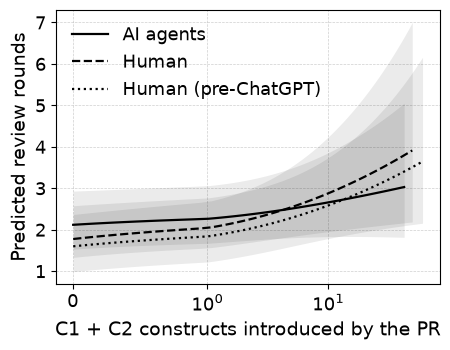

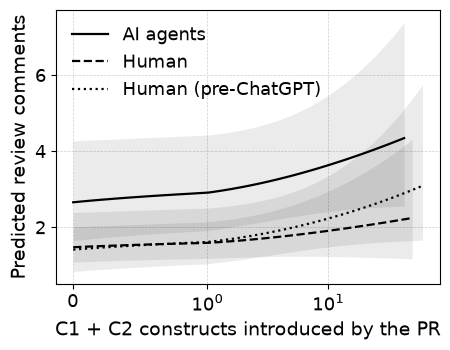

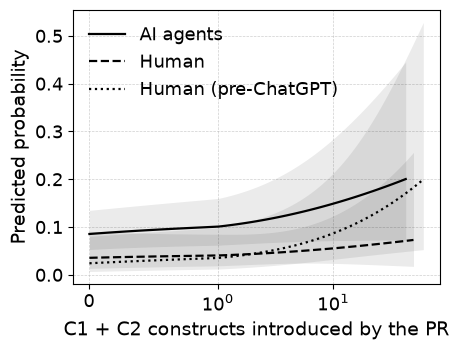

In [16]:
def design_info(res):
    """The fitted model's patsy design, named `model_spec` from statsmodels 0.15 on."""
    data = res.model.data
    for attr in ('model_spec', 'design_info'):
        if hasattr(data, attr):
            return getattr(data, attr)
    return data.orig_exog.design_info


def curve(res, d, outcome, iv, n=60):
    """Predicted outcome across the range of `iv`, other covariates at the group median."""
    lo, hi = d[iv].quantile([0.02, 0.98])
    grid = pd.DataFrame({iv: np.linspace(lo, hi, n)})
    for c in ['log_add', 'log_del', 'log_files']:
        grid[c] = d[c].median()
    grid['n_reviews_bot'] = d['n_reviews_bot'].fillna(0).median()
    grid['task'] = pd.Categorical(['feat'] * n, categories=TASK_ORDER)

    X = dmatrix(design_info(res), grid, return_type='dataframe')
    beta = res.params[X.columns]
    V = res.cov_params().loc[X.columns, X.columns]
    xb = X.values @ beta.values
    se = np.sqrt(np.einsum('ij,jk,ik->i', X.values, V.values, X.values))
    link = (lambda v: 1 / (1 + np.exp(-v))) if outcome == 'changes' else np.exp
    return grid[iv].values, link(xb), link(xb - 1.96 * se), link(xb + 1.96 * se)


LS = ['-', '--', ':']
for outcome in OUTCOMES:
    fig, ax = plt.subplots(figsize=(4.6, 3.6))
    for i, g in enumerate(GROUPS):
        d = df[df.group == g]
        res = fits[(g, outcome, 'c1c2_z')]
        x, y, lo, hi = curve(res, d, outcome, 'c1c2_z')
        xr = x * SD['log_c1c2'] + df['log_c1c2'].mean()      # back to log(1 + C1+C2)
        xc = np.expm1(xr)                                     # back to the C1+C2 count
        ax.plot(xc, y, ls=LS[i], color='black', lw=1.6, label=g)
        ax.fill_between(xc, lo, hi, color='black', alpha=0.08, lw=0)
    ax.set_xscale('symlog', linthresh=1)
    ax.set_xlabel('C1 + C2 constructs introduced by the PR', fontsize=14)
    ax.set_ylabel(('Predicted probability' if outcome == 'changes'
                   else f'Predicted {OUTCOMES[outcome].lower()}'), fontsize=14)
    ax.grid(True, ls='--', lw=0.5, alpha=0.6)
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=13)
    ax.legend(fontsize=13, frameon=False)  # each panel is a standalone subfigure
    fig.tight_layout()
    for ext in ('pdf', 'png'):
        fig.savefig(os.path.join(FIG_DIR, f'rq4_predicted_effort_{outcome}.{ext}'),
                    bbox_inches='tight', dpi=200 if ext == 'png' else None)
    plt.show()


## 8. LaTeX tables

In [17]:
def to_tex(frame, name, **kw):
    path = os.path.join(TAB_DIR, name + '.tex')
    frame.to_latex(path, **kw)
    print('wrote', os.path.relpath(path, ROOT))


to_tex(descriptives, 'review_effort_descriptives', float_format='%.1f')
to_tex(main_tab, 'main_models', escape=True)
to_tex(pool_tab, 'pooled_interaction', escape=True)
to_tex(rob_tab, 'robustness', escape=True, na_rep='--')
to_tex(zinb.set_index(['group', 'outcome']), 'zinb_comparison', float_format='%.2f')
to_tex(spear.pivot_table(index=['group', 'predictor'], columns='outcome',
                         values=['rho', 'p_holm']), 'raw_spearman', float_format='%.3f')

wrote rq4/tables/review_effort_descriptives.tex
wrote rq4/tables/main_models.tex
wrote rq4/tables/pooled_interaction.tex
wrote rq4/tables/robustness.tex
wrote rq4/tables/zinb_comparison.tex
wrote rq4/tables/raw_spearman.tex


## 9. The numbers that go into the paper

In [18]:
print('=' * 78)
print('RQ4 SUMMARY')
print('=' * 78)
print(f'Sample: {len(df)} PRs across {df.repo.nunique()} repositories '
      f'({", ".join(f"{g}: {n}" for g, n in df.groupby("group", observed=True).size().items())})')
print(f'Human-only comment counts: {HUMAN_COMMENTS}')
print()
print('-- review effort available to explain --')
for g, d in df.groupby('group', observed=True):
    print(f'  {g:22s} zero human reviews {100*(d.rounds==0).mean():5.1f}%   '
          f'zero human comments {100*(d.comments==0).mean():5.1f}%   '
          f'median comments {d.comments.median():.0f}   '
          f'changes requested {100*d.changes.mean():.1f}%')
print()
print('-- proficiency effect, size-controlled (1 SD, Holm-adjusted within group) --')
for _, r in models.sort_values(['iv', 'outcome', 'group']).iterrows():
    sig = 'SIGNIFICANT' if r.p_holm < 0.05 else 'n.s.'
    print(f'  {IVS[r.iv]:22s} {OUTCOMES[r.outcome]:18s} {r.group:22s} '
          f'{r.est:5.2f} [{r.lo:.2f}, {r.hi:.2f}]  p={r.p_holm:.4f}  {sig}')
print()
print('-- slope differences vs. AI agents --')
for _, r in pooled[pooled.term != 'AI agents (reference slope)'].iterrows():
    sig = 'SIGNIFICANT' if r.p_holm < 0.05 else 'n.s.'
    print(f'  {IVS[r.iv]:22s} {OUTCOMES[r.outcome]:18s} {r.term:34s} '
          f'{r.est:5.2f} [{r.lo:.2f}, {r.hi:.2f}]  p={r.p:.4f}  p_holm={r.p_holm:.4f}  {sig}')

RQ4 SUMMARY
Sample: 1468 PRs across 234 repositories (AI agents: 479, Human: 524, Human (pre-ChatGPT): 465)
Human-only comment counts: True

-- review effort available to explain --
  AI agents              zero human reviews  32.2%   zero human comments  40.5%   median comments 1   changes requested 10.4%
  Human                  zero human reviews  29.8%   zero human comments  52.3%   median comments 0   changes requested 5.0%
  Human (pre-ChatGPT)    zero human reviews  37.2%   zero human comments  56.8%   median comments 0   changes requested 4.7%

-- proficiency effect, size-controlled (1 SD, Holm-adjusted within group) --
  C1+C2 constructs       Changes requested  AI agents               1.35 [0.96, 1.89]  p=0.2454  n.s.
  C1+C2 constructs       Changes requested  Human                   1.25 [0.69, 2.24]  p=0.4591  n.s.
  C1+C2 constructs       Changes requested  Human (pre-ChatGPT)     1.90 [1.12, 3.23]  p=0.0533  n.s.
  C1+C2 constructs       Review comments    AI agents     